## Objective

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using historical trading data from Hyperliquid.

The goal is to uncover patterns that can help understand how market sentiment influences trading behavior and profitability.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better looking plots
plt.style.use("ggplot")

# Loading the Datasets

In [5]:
historical_data = pd.read_csv("/content/historical_data.csv")

fear_greed = pd.read_csv("/content/fear_greed_index.csv")

In [6]:
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# Data Understanding


In [8]:
print("Historical Data Shape")
print(historical_data.shape)

print()

print("Fear Greed Shape")
print(fear_greed.shape)

Historical Data Shape
(211224, 16)

Fear Greed Shape
(2644, 4)


In [9]:
historical_data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [10]:
fear_greed.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [11]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


# Missing Values


In [13]:
historical_data.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [14]:
fear_greed.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [16]:
historical_data.duplicated().sum()

np.int64(0)

In [15]:
fear_greed.duplicated().sum()

np.int64(0)

# Statistical Summary


In [17]:
historical_data.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


# Data Cleaning and Preparation


In [18]:
print("Historical Data Duplicates :", historical_data.duplicated().sum())
print("Fear & Greed Duplicates :", fear_greed.duplicated().sum())

Historical Data Duplicates : 0
Fear & Greed Duplicates : 0


In [19]:
historical_data["Timestamp IST"] = pd.to_datetime(
    historical_data["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

fear_greed["date"] = pd.to_datetime(fear_greed["date"])

In [20]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [21]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [22]:
historical_data["Date"] = historical_data["Timestamp IST"].dt.date

fear_greed["Date"] = fear_greed["date"].dt.date

In [23]:
historical_data[["Timestamp IST", "Date"]].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [24]:
fear_greed[["date", "Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [25]:
print("Historical Data")
print(historical_data["Date"].min())
print(historical_data["Date"].max())

Historical Data
2023-05-01
2025-05-01


In [26]:
print("Fear & Greed")
print(fear_greed["Date"].min())
print(fear_greed["Date"].max())

Fear & Greed
2018-02-01
2025-05-02


# Merging Historical Data with Fear & Greed Dataset


In [27]:
merged_data = pd.merge(
    historical_data,
    fear_greed[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

In [28]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [29]:
print("Merged Dataset Shape")
print(merged_data.shape)

Merged Dataset Shape
(211224, 19)


In [30]:
merged_data.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


# Exploratory Data Analysis


In [31]:
print("Total Trades :", len(merged_data))

Total Trades : 211224


In [32]:
merged_data["Account"].nunique()

32

In [33]:
merged_data["Coin"].value_counts()

,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
...,...
@18,1
@30,1
@25,1


In [34]:
merged_data["Side"].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [35]:
merged_data["Closed PnL"].mean()

np.float64(48.74900079269401)

In [36]:
merged_data["Closed PnL"].max()

135329.0901

In [37]:
merged_data["Closed PnL"].min()

-117990.1041

In [38]:
merged_data["Fee"].mean()

np.float64(1.163966786755912)

In [39]:
merged_data["Size USD"].mean()

np.float64(5639.4512103738225)

# Relationship Between Market Sentiment and Trader Performance


In [40]:
merged_data.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [41]:
merged_data.groupby("classification")["Closed PnL"].sum()

,Closed PnL
classification,
Extreme Fear,7.391102e+05
Extreme Greed,2.715171e+06
Fear,3.357155e+06
Greed,2.150129e+06
Neutral,1.292921e+06


In [42]:
merged_data.groupby("classification")["Closed PnL"].median()

,Closed PnL
classification,
Extreme Fear,0.0
Extreme Greed,0.0
Fear,0.0
Greed,0.0
Neutral,0.0


In [43]:
merged_data.groupby("classification").size()

,0
classification,
Extreme Fear,21400
Extreme Greed,39992
Fear,61837
Greed,50303
Neutral,37686


In [44]:
merged_data.groupby("classification")["Size USD"].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


In [45]:
merged_data.groupby("classification")["Execution Price"].mean()

,Execution Price
classification,
Extreme Fear,7054.795108
Extreme Greed,6082.195865
Fear,14152.620222
Greed,13411.276344
Neutral,12393.692779


In [46]:
merged_data["Trade Result"] = merged_data["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

In [47]:
merged_data.groupby("classification")["Trade Result"].value_counts()

classification  Trade Result
Extreme Fear    Loss            13469
                Profit           7931
Extreme Greed   Loss            21398
                Profit          18594
Fear            Loss            35818
                Profit          26019
Greed           Loss            30945
                Profit          19358
Neutral         Loss            22725
                Profit          14961
Name: count, dtype: int64

# Data Visualization


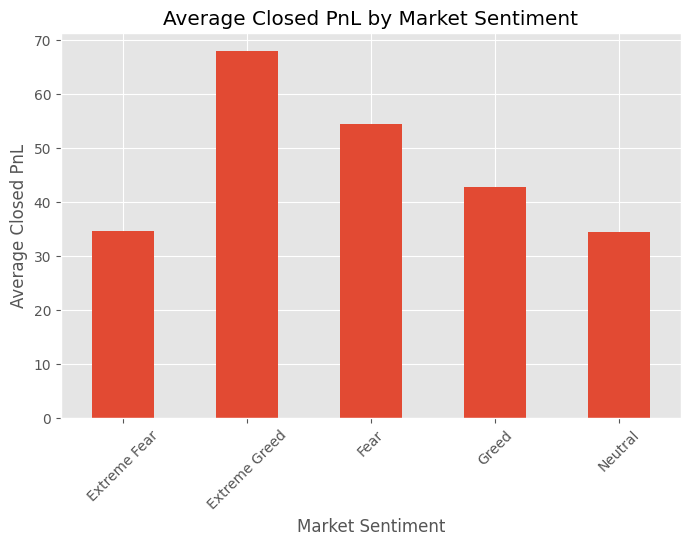

In [48]:
plt.figure(figsize=(8,5))

avg_profit = merged_data.groupby("classification")["Closed PnL"].mean()

avg_profit.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)

plt.show()

### Observation

- Extreme Greed produced the highest average Closed PnL per trade.
- Fear generated high average profits but lower than Extreme Greed.

### Business Insight

Although Fear periods generated greater cumulative profits, Extreme Greed delivered better average profitability per trade, indicating that trade quality may improve during optimistic market conditions.

### Trading Recommendation

Market sentiment can be incorporated as an additional confirmation signal before entering trades. However, it should always be combined with technical analysis and proper risk management instead of being used independently.

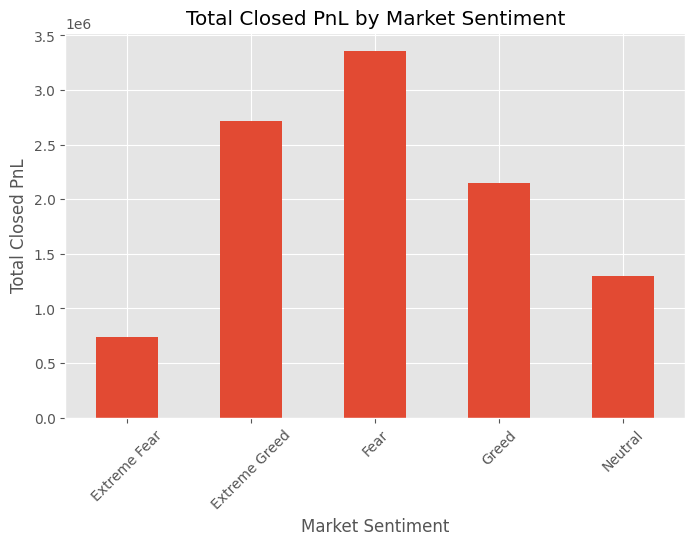

In [49]:
plt.figure(figsize=(8,5))

total_profit = merged_data.groupby("classification")["Closed PnL"].sum()

total_profit.plot(kind="bar")

plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)

plt.show()

### Observation

- Fear recorded the highest Total Closed PnL, followed by Extreme Greed and Greed.
- Extreme Fear generated the lowest Total Closed PnL among all market sentiments.

### Business Insight

The higher Total Closed PnL during Fear suggests that traders were more active and generated greater cumulative profits during volatile market conditions. However, this reflects overall market activity rather than higher profitability per individual trade.

### Trading Recommendation

Traders can expect increased trading opportunities during Fear periods due to higher market participation. However, increased activity should be accompanied by disciplined risk management because volatility also increases potential losses.


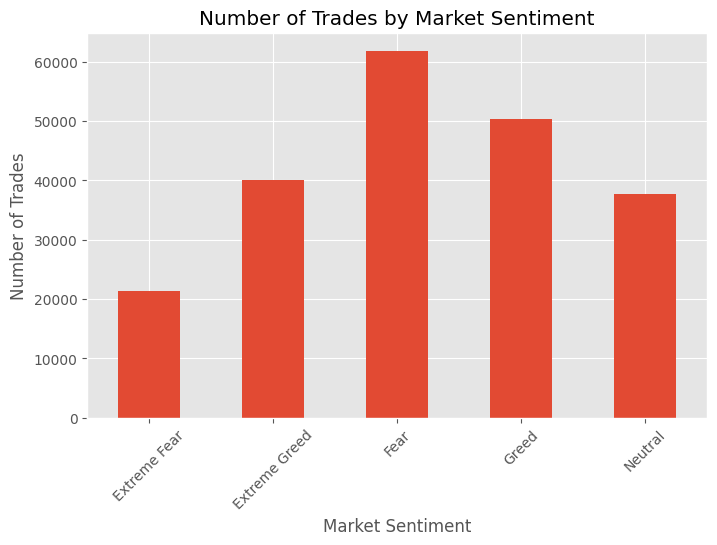

In [50]:
plt.figure(figsize=(8,5))

trade_count = merged_data.groupby("classification").size()

trade_count.plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

### Observation

- Fear markets recorded the highest number of trades.
- Extreme Fear showed the lowest trading activity.

### Business Insight

Trader participation increases significantly during Fear periods, suggesting that market volatility encourages more trading opportunities.

### Trading Recommendation

During Fear markets, traders should prepare for increased volatility and avoid emotional or impulsive trading by following predefined trading plans and position-sizing rules.


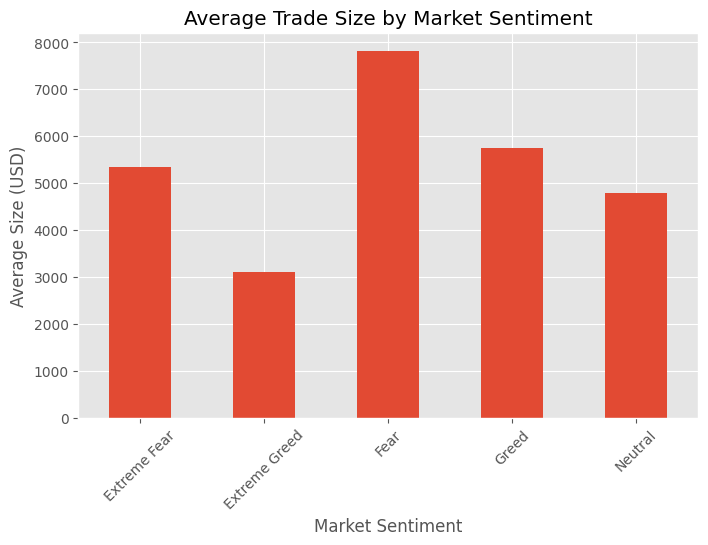

In [48]:
plt.figure(figsize=(8,5))

trade_size = merged_data.groupby("classification")["Size USD"].mean()

trade_size.plot(kind="bar")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Size (USD)")
plt.xticks(rotation=45)

plt.show()

### Observation

- The highest average trade size occurred during Fear.
- Extreme Greed recorded comparatively smaller average trade sizes.

### Business Insight

Traders tend to commit larger trading positions during Fear markets, possibly due to increased market volatility and the expectation of stronger price movements.

### Trading Recommendation

Larger trade sizes increase both potential returns and potential losses. Traders should adjust position sizes according to their risk tolerance and current market volatility.

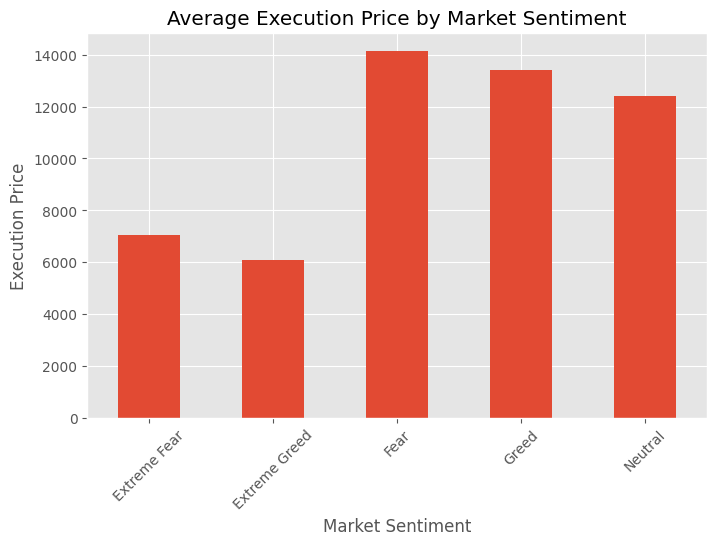

In [51]:
plt.figure(figsize=(8,5))

execution_price = merged_data.groupby("classification")["Execution Price"].mean()

execution_price.plot(kind="bar")

plt.title("Average Execution Price by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Execution Price")
plt.xticks(rotation=45)

plt.show()

### Observation

- Fear markets showed the highest average execution price.
- Extreme Fear recorded the lowest average execution price.

### Business Insight

Execution prices varied across different market sentiments, reflecting changing market conditions during different phases of the Fear and Greed cycle.

### Trading Recommendation

Execution price alone should not determine trading decisions. Traders should evaluate market sentiment together with price trends, support and resistance levels, and other technical indicators before entering positions.

<Figure size 1000x600 with 0 Axes>

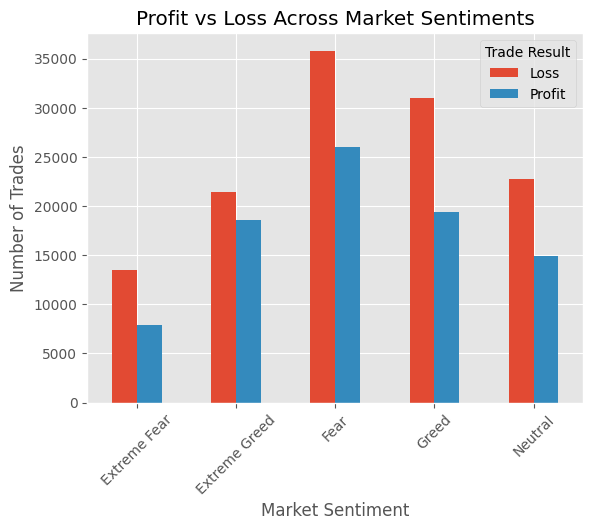

In [50]:
plt.figure(figsize=(10,6))

profit_loss = merged_data.groupby(
    ["classification", "Trade Result"]
).size().unstack()

profit_loss.plot(kind="bar")

plt.title("Profit vs Loss Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

### Observation

- Loss-making trades exceeded profitable trades across all market sentiment categories.
- Fear recorded both the highest number of profitable trades and the highest number of losing trades due to greater trading activity.

### Business Insight

Market sentiment alone does not guarantee profitable trading. Even during favorable market conditions, traders experienced substantial losses, highlighting the importance of trading discipline.

### Trading Recommendation

Market sentiment should be treated as a supporting indicator rather than the sole basis for trading decisions. Combining sentiment analysis with technical indicators and proper risk management can improve trading performance.


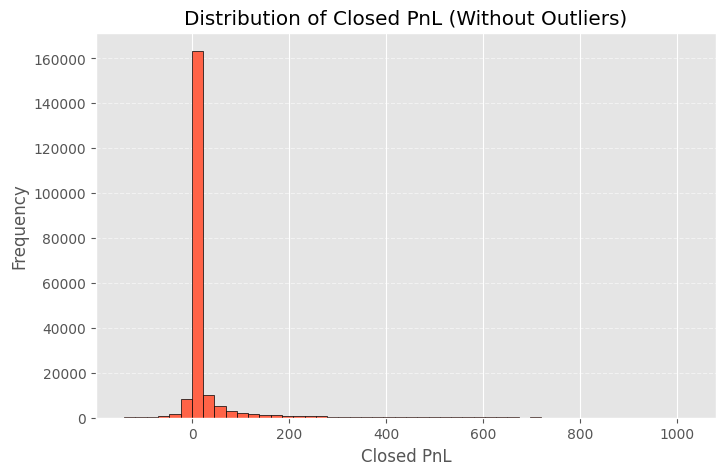

In [51]:
# Remove extreme outliers from Closed PnL using 1st and 99th percentiles

pnl = merged_data["Closed PnL"]

# Calculate lower and upper percentile limits
lower = pnl.quantile(0.01)   # 1st percentile
upper = pnl.quantile(0.99)   # 99th percentile

# Filter the data
pnl_filtered = pnl[(pnl >= lower) & (pnl <= upper)]

# Plot histogram
plt.figure(figsize=(8,5))

plt.hist(
    pnl_filtered,
    bins=50,
    color="tomato",
    edgecolor="black"
)

plt.title("Distribution of Closed PnL (Without Outliers)")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

- Most trades have Closed PnL values clustered close to zero, indicating that the majority of trades resulted in relatively small profits or losses.
- The frequency decreases as Closed PnL increases, showing that large profit-making trades are relatively uncommon.
- After removing outliers, the distribution highlights the overall trading pattern more clearly without being dominated by extreme values.

### Business Insight

The distribution indicates that traders typically experience small gains or losses, while exceptionally high profits occur infrequently. This suggests that consistent profitability is more likely achieved through multiple moderate gains rather than relying on a few exceptionally profitable trades.

### Trading Recommendation

Traders should prioritize consistency and disciplined risk management instead of attempting to capture rare, exceptionally large profits. A strategy focused on stable returns over multiple trades is likely to be more sustainable in the long term.

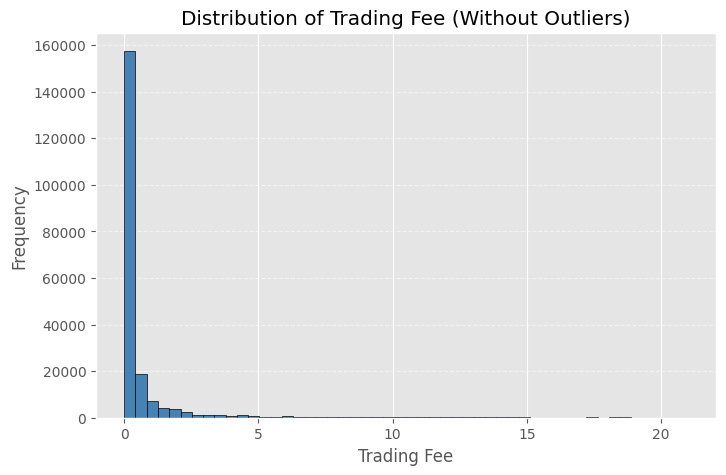

In [52]:
# Remove extreme outliers from Fee using 1st and 99th percentiles

fee = merged_data["Fee"]

# Calculate lower and upper percentile limits
lower = fee.quantile(0.01)   # 1st percentile
upper = fee.quantile(0.99)   # 99th percentile

# Filter the data
fee_filtered = fee[(fee >= lower) & (fee <= upper)]

# Plot histogram
plt.figure(figsize=(8,5))

plt.hist(
    fee_filtered,
    bins=50,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Trading Fee (Without Outliers)")
plt.xlabel("Trading Fee")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

- Most trades incurred relatively low transaction fees, with only a small number of trades having higher fees.
- The distribution is positively skewed, indicating that high-fee trades are much less frequent than low-fee trades.
- Removing outliers provides a clearer understanding of the typical trading fee paid by most traders.

### Business Insight

The majority of trading activity involves relatively low transaction costs. Higher trading fees are associated with fewer trades and are likely linked to larger trading positions or higher-value transactions.

### Trading Recommendation

Traders should consider transaction costs when determining trade size and frequency. Optimizing position size can help reduce unnecessary trading expenses and improve overall net profitability.

# Win Rate by Market Sentiment

This visualization shows the percentage of profitable trades under each market sentiment.


/tmp/ipykernel_874/3571424237.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


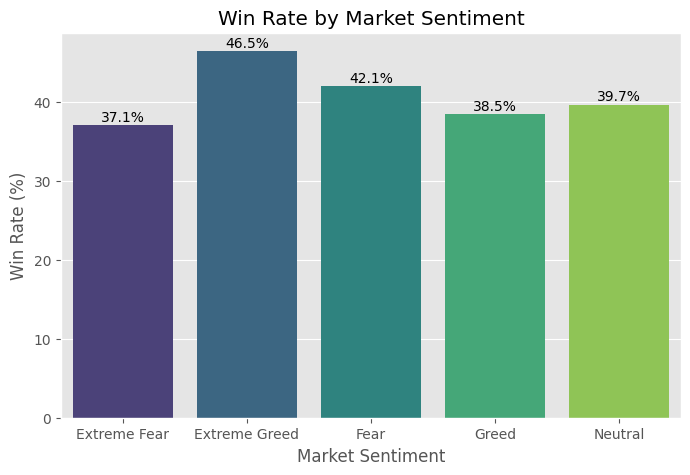

In [53]:


win_rate = (
    merged_data.groupby("classification")["Trade Result"]
    .apply(lambda x: (x == "Profit").mean() * 100)
    .reset_index(name="Win Rate (%)")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=win_rate,
    x="classification",
    y="Win Rate (%)",
    palette="viridis"
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

for i,v in enumerate(win_rate["Win Rate (%)"]):
    plt.text(i,v+0.5,f"{v:.1f}%",ha="center")

plt.show()



### Observation

- Extreme Greed achieved the highest win rate (46.5%), followed by Fear (42.1%).
- Extreme Fear recorded the lowest win rate (37.1%), indicating comparatively fewer profitable trades.

### Business Insight

The variation in win rates across market sentiments suggests that trader performance is influenced by overall market psychology. Positive market sentiment appears to be associated with a higher proportion of successful trades.

### Trading Recommendation

Market sentiment can be used as an additional confirmation signal before opening new positions. However, traders should combine sentiment analysis with technical indicators and risk management strategies rather than relying solely on market sentiment.



# Average Fee Analysis

/tmp/ipykernel_945/510370861.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


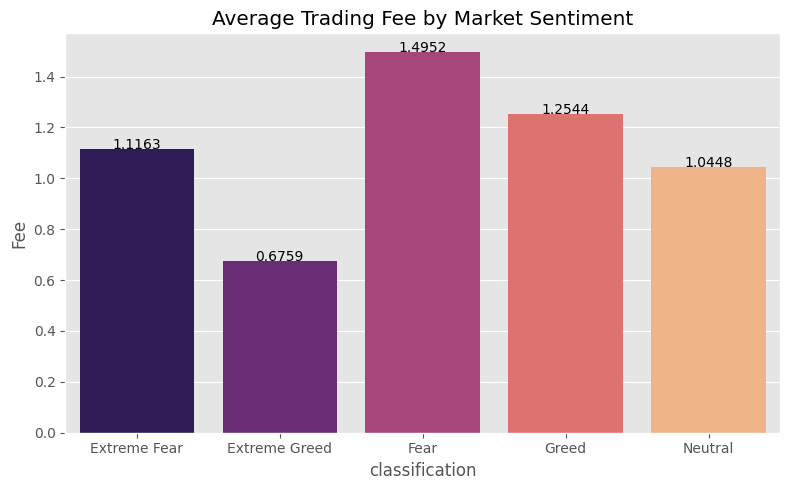

In [52]:
# ==============================
# Average Fee by Market Sentiment
# ==============================

avg_fee = (
    merged_data.groupby("classification")["Fee"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_fee,
    x="classification",
    y="Fee",
    palette="magma"
)

plt.title("Average Trading Fee by Market Sentiment")

for i, v in enumerate(avg_fee["Fee"]):
    plt.text(i, v, f"{v:.4f}", ha="center")

plt.tight_layout()
plt.show()



### Observation

- Fear recorded the highest average trading fee, while Extreme Greed showed the lowest average trading fee.
- The variation reflects differences in average trade size and trading activity across market sentiments.

### Business Insight

Higher trading activity and larger average trade sizes during Fear periods contribute to increased transaction costs.

### Trading Recommendation

During highly active market conditions, traders should account for transaction costs when determining trade size to ensure that trading fees do not significantly reduce net profitability.

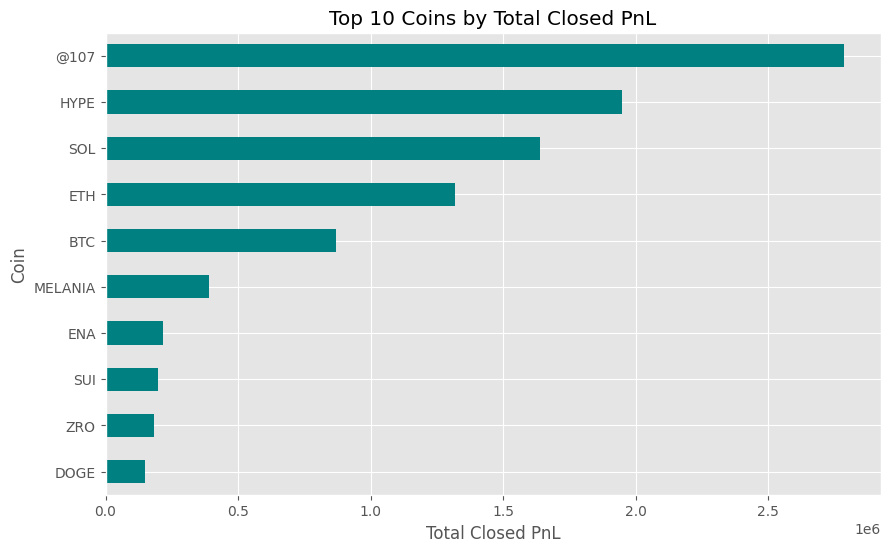

In [53]:
# ==============================
# Top 10 Coins
# ==============================

top_coins = (
    merged_data.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_coins.sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Total Closed PnL")

plt.show()



### Observation

- A limited number of trading pairs contributed the majority of cumulative Closed PnL.
- Coins such as @107, HYPE, SOL, and ETH generated the highest total profits compared with the remaining assets.

### Business Insight

Profitability differs across trading assets, indicating that asset selection plays an important role in trading performance.

### Trading Recommendation

Traders should evaluate historical performance alongside market conditions when selecting trading assets rather than treating all assets equally.

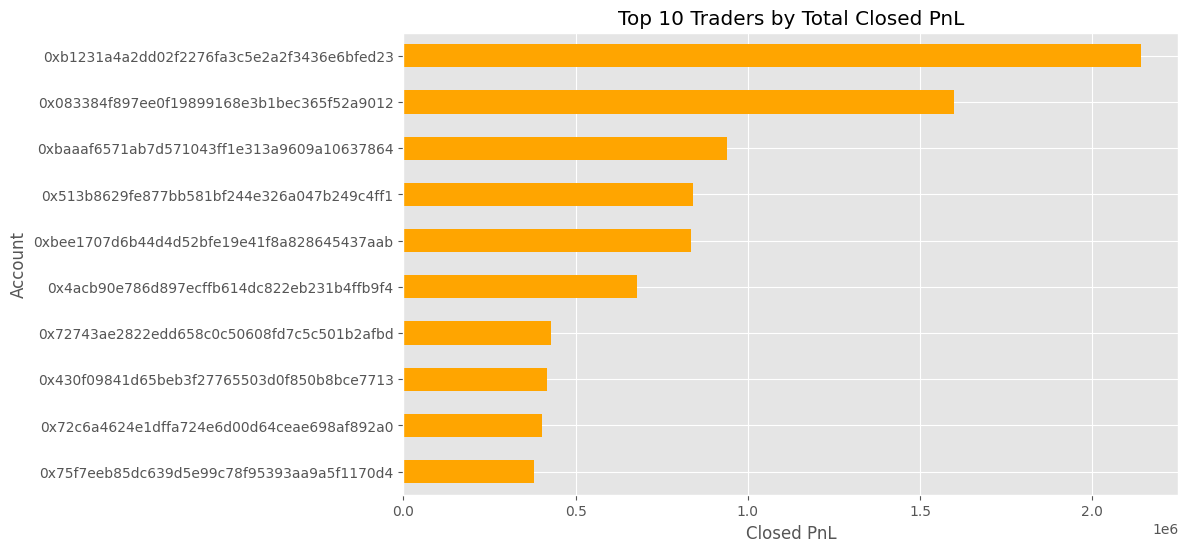

In [56]:
# ==============================
# Top Traders
# ==============================

top_traders = (
    merged_data.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_traders.sort_values().plot(
    kind="barh",
    color="orange"
)

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Closed PnL")

plt.show()



### Observation

- A small group of traders generated significantly higher cumulative Closed PnL than others.
- The highest-performing trader substantially outperformed the remaining traders.

### Business Insight

Trader performance varies considerably across accounts, suggesting that trading strategy, experience, and risk management practices have a significant impact on long-term profitability.

### Trading Recommendation

Analyzing the trading behavior of consistently profitable traders may help identify effective trading strategies and improve decision-making for other market participants.


/tmp/ipykernel_874/1906078164.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


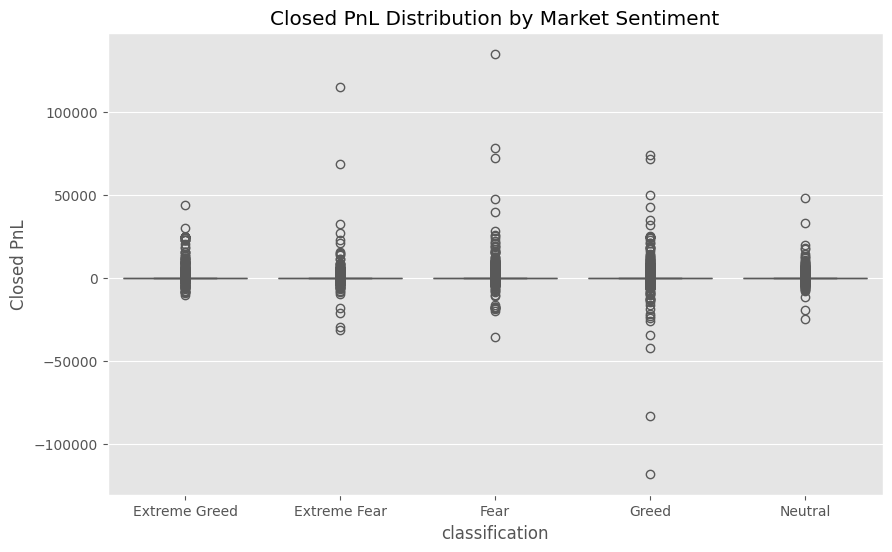

In [57]:
# ==============================
# Closed PnL Boxplot
# ==============================

plt.figure(figsize=(10,6))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=merged_data,
    palette="Set2"
)

plt.title("Closed PnL Distribution by Market Sentiment")

plt.show()

### Observation

- Most trades across all market sentiments generated Closed PnL values clustered near zero.
- Several extreme positive and negative outliers are present, indicating occasional exceptionally profitable and highly unprofitable trades.

### Business Insight

The presence of numerous outliers suggests that cryptocurrency trading involves substantial variability and risk regardless of market sentiment.

### Trading Recommendation

Traders should implement stop-loss mechanisms, position-sizing strategies, and disciplined risk management to limit the impact of extreme market movements.

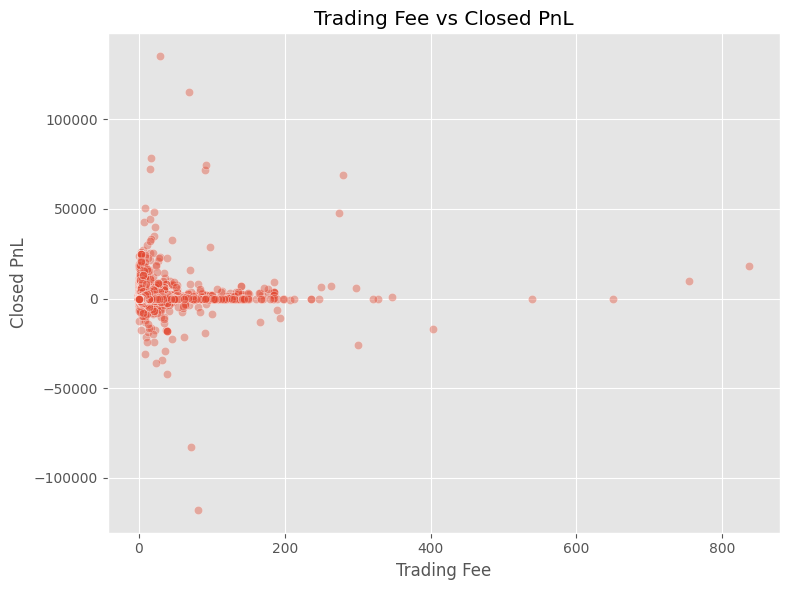

In [54]:
# ==============================
# Fee vs Closed PnL
# ==============================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_data,
    x="Fee",
    y="Closed PnL",
    alpha=0.4
)

plt.title("Trading Fee vs Closed PnL")
plt.xlabel("Trading Fee")
plt.ylabel("Closed PnL")

plt.tight_layout()
plt.show()

### Observation

- Most trades incurred relatively low transaction fees.
- Higher trading fees were generally associated with larger trades, but they did not consistently correspond to higher profits.

### Business Insight

Transaction fees increase with trade size, yet higher trading costs do not necessarily improve profitability. This highlights the importance of considering transaction costs during trade planning.

### Trading Recommendation

Traders should optimize trade size to balance expected returns against transaction costs and avoid unnecessary reduction in net profitability due to excessive fees.

In [56]:
# ==============================
# Summary Statistics
# ==============================

summary = merged_data.groupby("classification").agg(
    Total_Trades=("Closed PnL", "count"),
    Total_Profit=("Closed PnL", "sum"),
    Average_Profit=("Closed PnL", "mean"),
    Median_Profit=("Closed PnL", "median"),
    Average_Trade_Size=("Size USD", "mean"),
    Average_Fee=("Fee", "mean")
)

summary

,Total_Trades,Total_Profit,Average_Profit,Median_Profit,Average_Trade_Size,Average_Fee
classification,,,,,,
Extreme Fear,21400,7.391102e+05,34.537862,0.0,5349.731843,1.116291
Extreme Greed,39992,2.715171e+06,67.892861,0.0,3112.251565,0.675902
Fear,61837,3.357155e+06,54.290400,0.0,7816.109931,1.495172
Greed,50303,2.150129e+06,42.743559,0.0,5736.884375,1.254372
Neutral,37686,1.292921e+06,34.307718,0.0,4782.732661,1.044798


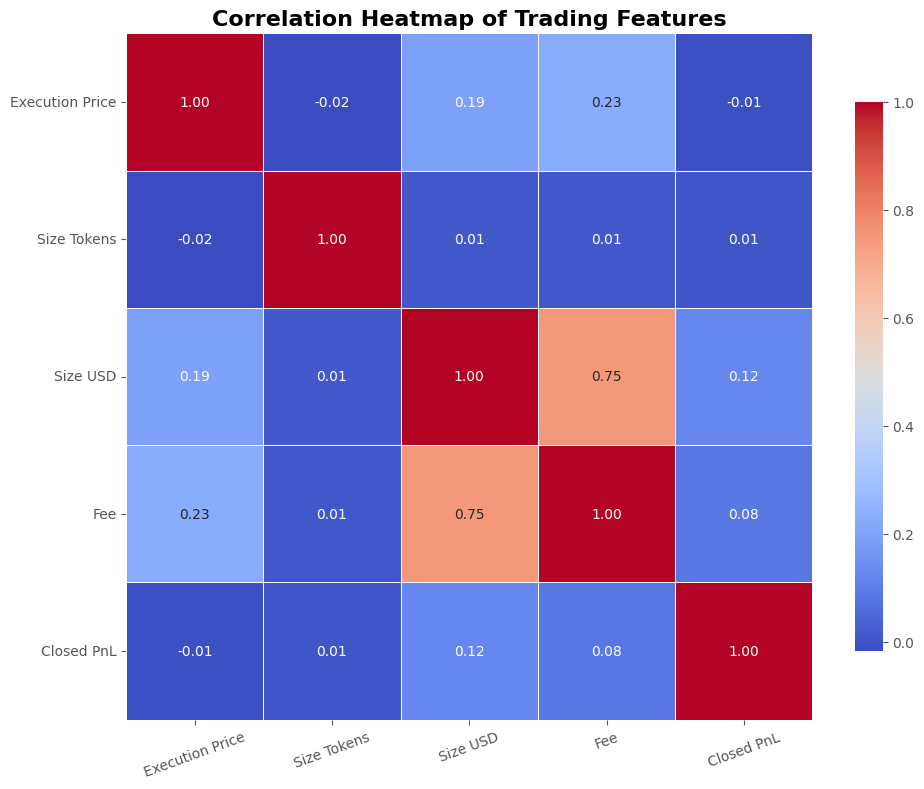

In [58]:
# ==========================================
# Correlation Heatmap
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only meaningful numerical columns
numeric_data = merged_data[
    [
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Fee",
        "Closed PnL"
    ]
]

# Calculate correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Correlation Heatmap of Trading Features",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=20)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation

- Size USD and Trading Fee exhibit a strong positive correlation (0.75), indicating that larger trades incur higher transaction costs.
- Closed PnL shows only weak correlations with the remaining numerical variables.

### Business Insight

Trader profitability cannot be explained by any single numerical feature. Instead, multiple market factors and trading decisions collectively influence final trading outcomes.

### Trading Recommendation

Trading decisions should incorporate multiple indicators—including market sentiment, technical analysis, and risk management—rather than relying on a single variable to predict profitability.

## Conclusion






This project analyzed the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data. After preprocessing and merging the datasets based on the trading date, exploratory data analysis (EDA) was performed to identify patterns between market sentiment and trading behavior.

The analysis revealed the following key findings:

Fear periods recorded the highest number of trades, indicating that traders were more active during uncertain market conditions.
Extreme Greed showed the highest average Closed PnL, suggesting that traders achieved better average profits during strong bullish market sentiment.
The Fear category generated the highest total Closed PnL because it contained the largest number of trades.
The average trade size (USD) and execution price varied across different market sentiment categories, indicating that trader behavior changes with market conditions.
The Profit vs Loss analysis showed that losses were more frequent than profits across all market sentiment categories, although profitable trades were still significant.
The correlation heatmap indicated that most numerical features had weak correlations with Closed PnL, suggesting that trader profitability depends on multiple factors rather than a single variable.
Histograms of Closed PnL and Trading Fee showed highly skewed distributions, with most values concentrated near zero and a small number of large outliers. Removing these outliers provided a clearer understanding of the underlying data distribution.

Overall, the analysis suggests that market sentiment influences trading activity and performance, but it is not the only factor affecting profitability. Additional variables such as trading strategy, market volatility, leverage, and position management are likely to play an important role. Further analysis using predictive machine learning models could provide deeper insights into the relationship between market sentiment and trading outcomes.
